# Transient / Persistent OI Shock Audit

이 노트북은 **Transient / Persistent OI Shock**를 실제 Binance BTCUSDT perpetual 데이터로 검증한다.

핵심 질문은 다음과 같다.

1. OI가 평소보다 크게 튄 구간을 robust하게 탐지할 수 있는가?
2. Shock 이후 OI가 원래 상태로 돌아오는지, 아니면 높은/낮은 상태가 유지되는지 구분할 수 있는가?
3. Transient shock는 range 전략의 risk-off 필터로, Persistent shock는 breakout/trend-following 후보로 사용할 수 있는가?
4. 이 신호를 백테스트에 넣었을 때 수익률, 승률, PF, MDD, 거래 수가 어떻게 바뀌는가?

이 노트북의 목적은 단순히 “OI가 튀었다”를 보는 것이 아니라, **그 충격이 일시적 노이즈인지, 시장 상태 변화인지**를 구분하고 전략에 어떻게 반영할지 확인하는 것이다.

## 1. Concept

OI Shock는 Open Interest가 평소 상태에서 갑자기 크게 벗어나는 현상이다.

하지만 중요한 것은 shock 자체가 아니라, **shock 이후 원래 상태로 돌아왔는가**다.

```text
Transient Shock
평소 OI ────────╱╲────────
        크게 튐   다시 복귀

Persistent Shock
평소 OI ────────╱━━━━━━━
        크게 튐   높은 상태 유지
```

전략 해석은 다음처럼 나눌 수 있다.

- `Transient`: 일시적 청산/진입 충격 가능성. 기존 range 진입은 조심한다.
- `Persistent`: 새로운 포지션 구조가 시장에 남아 있을 가능성. 가격 박스 돌파와 함께 trend-following 후보로 본다.

## 2. Formula

먼저 baseline OI의 중심을 중앙값으로 잡는다.

$$
M_{base}=Median(OI_{base})
$$

Shock 크기는 baseline 중심에서 peak OI가 얼마나 벗어났는지로 정의한다.

$$
ShockSize = OI_{peak} - M_{base}
$$

Shock가 평소 변동 단위 대비 얼마나 큰지는 robust scale로 나눈다.

$$
ShockZ=
\frac{|ShockSize|}{RobustScale(OI_{base})}
$$

전체 OI 규모 대비 변화율도 함께 본다.

$$
ChangeRatio=
\frac{|ShockSize|}{|M_{base}|}
$$

Shock 후보 조건은 다음과 같다.

$$
ShockZ \geq \theta_z
\quad \text{and} \quad
ChangeRatio \geq \theta_r
$$

Shock 이후 미래 구간에서 baseline 중심에 얼마나 가까워졌는지를 되돌림 비율로 계산한다.

$$
ReversionFraction=
\frac{\min |OI_{future}-M_{base}|}{|ShockSize|}
$$

판단 조건은 다음과 같다.

$$
ReversionFraction \leq \alpha \Rightarrow Transient
$$

$$
ReversionFraction > \alpha \Rightarrow Persistent
$$

즉, shock 이후 남은 gap이 shock 크기의 일정 비율 이하로 줄면 transient, 그렇지 않으면 persistent로 본다.

## 3. Setup

In [19]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'takora-trading' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path(os.environ.get('TAKORA_DATA_ROOT', '/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))
OUTPUT_DIR = PROJECT_ROOT / 'research/notebooks/_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from research.microstructure_alpha.oi_box import detect_oi_box_ranges
from research.microstructure_alpha.box_event_signals import detect_transient_oi_shocks
from research.microstructure_alpha.box_strategy_backtest import (
    BoxStrategyConfig,
    build_box_strategy_frame,
    candidate_box_strategy_configs,
    optimize_box_strategy,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT, DATA_ROOT

(PosixPath('/Users/changminkim/Desktop/projects/equidice/takora-trading'),
 PosixPath('/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))

<!-- codex-cell-output-interpretation -->
#### 출력 해석

프로젝트 루트가 `takora-trading`으로 잡혔고, 데이터 루트는 로컬 exchange dataset 경로로 연결되었다. 이 셀은 노트북이 임의 샘플이 아니라 프로젝트 코드와 실제 저장 데이터셋을 기준으로 실행된다는 것을 확인하는 setup 단계다.


## 4. Analysis Window

기본 구간은 포트폴리오 진단 구간과 맞춘다.

- 시작: `2026-05-22 00:00:00`
- 종료: `2026-07-18 23:55:00`
- 봉: `5min`

구간을 바꾸려면 아래 변수만 수정하면 된다.

In [20]:
START_TIME = '2026-05-22 00:00:00'
END_TIME = '2026-07-18 23:55:00'
BAR_SIZE = '5m'

start_ts = pd.Timestamp(START_TIME)
end_ts = pd.Timestamp(END_TIME)
print(start_ts, '->', end_ts, BAR_SIZE)

2026-05-22 00:00:00 -> 2026-07-18 23:55:00 5m


## 5. Binance Price / OI Loader

사용 데이터:

- Binance BTCUSDT perpetual trades: 5분봉 OHLCV 생성
- Binance BTCUSDT perpetual open interest: 5분 단위 OI value 생성

OI는 가능하면 `sum_open_interest_value`를 사용하고, 값이 비어 있으면 `sum_open_interest × BTC close`로 USD 노출을 근사한다.

In [21]:
def date_filtered_paths(root: Path, pattern: str, start: pd.Timestamp, end: pd.Timestamp) -> list[Path]:
    paths = sorted(root.glob(pattern))
    dates = set(pd.date_range(start.normalize(), end.normalize(), freq='D').strftime('%Y-%m-%d'))
    selected = [path for path in paths if any(date in path.name for date in dates)]
    return selected if selected else paths


def parquet_timestamp_unit(path: Path, column: str) -> str:
    sample = pl.read_parquet(path, columns=[column], n_rows=1)
    value = int(sample[column][0])
    if value > 10**17:
        return 'ns'
    if value > 10**14:
        return 'us'
    if value > 10**11:
        return 'ms'
    return 's'


def load_binance_trades_ohlcv(
    *,
    data_root: Path = DATA_ROOT,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(
        data_root,
        'binance/assets/btcusdt/future/trades/hour/*.parquet',
        start,
        end,
    )
    if not paths:
        raise FileNotFoundError('No Binance trades parquet files found')

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('trade_time'), time_unit='ms').alias('timestamp'),
            pl.col('price').cast(pl.Float64, strict=False).alias('price'),
            pl.col('quantity').cast(pl.Float64, strict=False).alias('quantity'),
        ])
        .filter(pl.col('timestamp') >= start.to_pydatetime())
        .filter(pl.col('timestamp') <= end.to_pydatetime())
        .drop_nulls(['timestamp', 'price', 'quantity'])
        .filter((pl.col('price') > 0) & (pl.col('quantity') > 0))
        .sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([
            pl.col('price').first().alias('open'),
            pl.col('price').max().alias('high'),
            pl.col('price').min().alias('low'),
            pl.col('price').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.len().alias('trade_count'),
        ])
    )
    out = lf.collect().to_pandas()
    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    return out.dropna(subset=['open', 'high', 'low', 'close']).sort_values('timestamp').reset_index(drop=True)


def load_binance_open_interest(
    price_frame: pd.DataFrame,
    *,
    data_root: Path = DATA_ROOT,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(
        data_root,
        'binance/assets/btcusdt/future/openinterest/hour/*.parquet',
        start,
        end,
    )
    if not paths:
        raise FileNotFoundError('No Binance openinterest parquet files found')

    unit = parquet_timestamp_unit(paths[0], 'timestamp')
    sample_columns = pl.read_parquet(paths[0], n_rows=1).columns
    has_value = 'sum_open_interest_value' in sample_columns
    value_expr = (
        pl.col('sum_open_interest_value').cast(pl.Float64, strict=False).alias('oi_value_raw')
        if has_value else
        pl.lit(None, dtype=pl.Float64).alias('oi_value_raw')
    )

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('timestamp'), time_unit=unit).alias('timestamp_dt'),
            pl.col('sum_open_interest').cast(pl.Float64, strict=False).alias('oi_amount'),
            value_expr,
        ])
        .filter(pl.col('timestamp_dt') >= start.to_pydatetime())
        .filter(pl.col('timestamp_dt') <= end.to_pydatetime())
        .drop_nulls(['timestamp_dt', 'oi_amount'])
        .sort('timestamp_dt')
        .group_by_dynamic('timestamp_dt', every=bar_size, period=bar_size)
        .agg([
            pl.col('oi_amount').last().alias('oi_amount'),
            pl.col('oi_value_raw').last().alias('oi_value_raw'),
        ])
    )
    oi = lf.collect().to_pandas().rename(columns={'timestamp_dt': 'timestamp'})
    oi['timestamp'] = pd.to_datetime(oi['timestamp']).astype('datetime64[ns]')
    oi = oi.sort_values('timestamp').reset_index(drop=True)

    price_close = price_frame[['timestamp', 'close']].copy().sort_values('timestamp')
    oi = pd.merge_asof(oi, price_close, on='timestamp', direction='backward')
    oi['oi_value_usd'] = pd.to_numeric(oi['oi_value_raw'], errors='coerce')
    fallback_value = pd.to_numeric(oi['oi_amount'], errors='coerce') * pd.to_numeric(oi['close'], errors='coerce')
    oi['oi_value_usd'] = oi['oi_value_usd'].where(oi['oi_value_usd'].notna() & (oi['oi_value_usd'] > 0), fallback_value)
    oi = oi.dropna(subset=['oi_value_usd']).reset_index(drop=True)
    return oi[['timestamp', 'oi_amount', 'oi_value_raw', 'oi_value_usd']]

price_df = load_binance_trades_ohlcv()
oi_df = load_binance_open_interest(price_df)

common_start = max(price_df['timestamp'].min(), oi_df['timestamp'].min())
common_end = min(price_df['timestamp'].max(), oi_df['timestamp'].max())
price_df = price_df[(price_df['timestamp'] >= common_start) & (price_df['timestamp'] <= common_end)].reset_index(drop=True)
oi_df = oi_df[(oi_df['timestamp'] >= common_start) & (oi_df['timestamp'] <= common_end)].reset_index(drop=True)

print('price rows:', len(price_df), price_df['timestamp'].min(), '->', price_df['timestamp'].max())
print('oi rows:', len(oi_df), oi_df['timestamp'].min(), '->', oi_df['timestamp'].max())
display(price_df.head())
display(oi_df.head())

price rows: 16703 2026-05-22 00:00:00 -> 2026-07-18 23:50:00
oi rows: 16703 2026-05-22 00:00:00 -> 2026-07-18 23:50:00


,timestamp,open,high,low,close,volume,trade_count
0,2026-05-22 00:00:00,77586.3,77602.5,77480.0,77507.8,324.233,10270
1,2026-05-22 00:05:00,77507.9,77533.9,77497.5,77497.5,105.221,4533
2,2026-05-22 00:10:00,77497.5,77497.5,77405.4,77405.5,256.104,7238
3,2026-05-22 00:15:00,77405.4,77498.6,77374.4,77442.4,278.306,9473
4,2026-05-22 00:20:00,77442.3,77520.5,77441.2,77506.8,110.727,6209


,timestamp,oi_amount,oi_value_raw,oi_value_usd
0,2026-05-22 00:00:00,100697.616,7.812745e+09,7.812745e+09
1,2026-05-22 00:05:00,100753.997,7.809553e+09,7.809553e+09
2,2026-05-22 00:10:00,100756.618,7.808386e+09,7.808386e+09
3,2026-05-22 00:15:00,100781.085,7.801609e+09,7.801609e+09
4,2026-05-22 00:20:00,100789.294,7.805365e+09,7.805365e+09


## 6. Price Box / OI Box Detection

Shock 자체는 OI에서 탐지하지만, 전략에 쓰려면 price box와 OI box도 같이 필요하다.

- Price Box: range mean-reversion의 가격 기준
- OI Box: OI 상태가 안정적인 구간인지 확인하는 필터

In [22]:
price_boxes = detect_oi_box_ranges(
    price_df,
    timestamp_col='timestamp',
    value_col='close',
    min_bars=72,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
)

oi_boxes = detect_oi_box_ranges(
    oi_df,
    timestamp_col='timestamp',
    value_col='oi_value_usd',
    min_bars=72,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
)

print('price boxes:', len(price_boxes))
print('oi boxes:', len(oi_boxes))
display(pd.DataFrame([box.to_dict() for box in price_boxes]).head(10))
display(pd.DataFrame([box.to_dict() for box in oi_boxes]).head(10))

price boxes: 96
oi boxes: 100


,box_id,start,end,low,high,mid,width,bars,coverage,low_touches,high_touches,break_direction,score
0,0,2026-05-22 00:00:00,2026-05-22 13:55:00,77228.1016,77712.0884,77470.095,483.9868,168,0.839286,34,24,down,0.911607
1,1,2026-05-22 14:00:00,2026-05-22 19:55:00,76154.5960,76998.2640,76576.430,843.6680,72,0.861111,9,15,center_shift,0.886111
2,2,2026-05-22 20:00:00,2026-05-23 07:40:00,75316.7320,75986.1680,75651.450,669.4360,141,0.886525,21,18,down,0.937589
3,3,2026-05-23 07:45:00,2026-05-23 13:40:00,74554.7100,74933.7400,74744.225,379.0300,72,0.902778,10,10,up,0.909028
4,4,2026-05-23 13:45:00,2026-05-23 20:25:00,75244.5360,75973.3640,75608.950,728.8280,81,0.876543,9,13,up,0.908661
5,5,2026-05-23 20:30:00,2026-05-24 10:20:00,76618.5424,76962.7376,76790.640,344.1952,167,0.874251,30,24,up,0.930838
6,6,2026-05-24 10:25:00,2026-05-25 14:40:00,76485.5328,77496.2872,76990.910,1010.7544,340,0.855882,46,59,up,0.920735
7,7,2026-05-25 14:45:00,2026-05-26 00:10:00,77196.6444,77685.9556,77441.300,489.3112,114,0.885965,19,17,down,0.937281
8,8,2026-05-26 00:15:00,2026-05-26 10:20:00,76591.3976,76900.8624,76746.130,309.4648,122,0.860656,44,22,up,0.923361
9,9,2026-05-26 10:25:00,2026-05-26 17:15:00,76360.5432,77473.5168,76917.030,1112.9736,83,0.903614,13,11,down,0.926675


,box_id,start,end,low,high,mid,width,bars,coverage,low_touches,high_touches,break_direction,score
0,0,2026-05-22 00:00:00,2026-05-22 14:35:00,7.778075e+09,7.842697e+09,7.810386e+09,6.462177e+07,176,0.892045,27,21,up,0.940625
1,1,2026-05-22 14:40:00,2026-05-23 07:45:00,7.925722e+09,8.028669e+09,7.977195e+09,1.029469e+08,206,0.830097,25,27,down,0.906553
2,2,2026-05-23 07:50:00,2026-05-23 18:10:00,7.785499e+09,7.890332e+09,7.837916e+09,1.048325e+08,125,0.880000,14,23,up,0.934000
3,3,2026-05-23 18:15:00,2026-05-24 03:40:00,7.887175e+09,7.941154e+09,7.914165e+09,5.397846e+07,114,0.850877,19,13,down,0.917982
4,4,2026-05-24 03:45:00,2026-05-24 10:25:00,7.835975e+09,7.885223e+09,7.860599e+09,4.924811e+07,81,0.950617,12,15,down,0.949402
5,5,2026-05-24 10:30:00,2026-05-24 21:35:00,7.657460e+09,7.835944e+09,7.746702e+09,1.784839e+08,134,0.977612,40,20,down,0.987687
6,6,2026-05-24 21:40:00,2026-05-25 04:35:00,7.625508e+09,7.667956e+09,7.646732e+09,4.244738e+07,84,0.857143,12,12,up,0.902679
7,7,2026-05-25 04:40:00,2026-05-26 00:40:00,7.697311e+09,7.749907e+09,7.723609e+09,5.259577e+07,241,0.887967,43,34,down,0.938382
8,8,2026-05-26 00:45:00,2026-05-26 07:00:00,7.617433e+09,7.659959e+09,7.638696e+09,4.252601e+07,76,0.855263,11,16,down,0.889145
9,9,2026-05-26 07:05:00,2026-05-26 14:30:00,7.563930e+09,7.628028e+09,7.595979e+09,6.409787e+07,90,0.855556,17,11,down,0.911181


<!-- codex-cell-output-interpretation -->
#### 출력 해석

Price Box는 **96개**, OI Box는 **100개** 탐지되었다. 두 박스 수가 충분히 많기 때문에, 특정 몇 개 구간에만 의존하지 않고 여러 횡보/이탈 구간에서 OI shock의 의미를 비교할 수 있다.

Price Box는 실제 가격의 range 구조를 잡고, OI Box는 레버리지 포지션 규모가 안정적으로 유지되는 구간을 잡는다. 이후 shock 분석은 이 OI Box 상태가 깨지는 순간을 transient 또는 persistent로 분리하는 역할을 한다.


## 7. Detect Transient / Persistent OI Shock

여기서는 Binance OI value에서 shock를 탐지한다.

파라미터 의미:

- `baseline_bars`: 평소 OI 중심과 scale을 계산하는 과거 구간
- `shock_window_bars`: shock 후보를 찾는 짧은 구간
- `reversion_bars`: shock 이후 원래 상태로 돌아오는지 확인하는 미래 구간
- `shock_z`: robust scale 대비 shock 크기 기준
- `min_change_ratio`: OI 규모 대비 최소 변화율
- `max_reversion_fraction`: 이 값 이하로 되돌리면 transient

In [24]:
oi_shocks = detect_transient_oi_shocks(
    oi_df,
    timestamp_col='timestamp',
    value_col='oi_value_usd',
    baseline_bars=288,          # 24h on 5m bars
    shock_window_bars=6,        # 30m
    reversion_bars=72,          # 6h
    shock_z=5.0,
    min_change_ratio=0.008,
    max_reversion_fraction=0.35,
    cooldown_bars=72,
)

print('shock events:', len(oi_shocks))
if not oi_shocks.empty:
    print('transient:', int(oi_shocks['is_transient'].sum()))
    print('persistent:', int(oi_shocks['is_persistent'].sum()))

display_cols = [
    'event_time', 'baseline_start', 'baseline_end', 'baseline_median',
    'shock_value', 'shock_size', 'shock_abs', 'shock_z', 'change_ratio',
    'direction', 'reversion_time', 'reversion_fraction', 'is_transient', 'is_persistent',
]
display(oi_shocks[display_cols].head(30) if not oi_shocks.empty else oi_shocks)

shock events: 19
transient: 3
persistent: 16


,event_time,baseline_start,baseline_end,baseline_median,shock_value,shock_size,shock_abs,shock_z,change_ratio,direction,reversion_time,reversion_fraction,is_transient,is_persistent
0,2026-05-24 14:15:00,2026-05-23 13:50:00,2026-05-24 13:45:00,7.879933e+09,7.719325e+09,-1.606086e+08,1.606086e+08,5.316922,0.020382,down,NaT,1.124109,False,True
1,2026-05-26 07:15:00,2026-05-25 06:50:00,2026-05-26 06:45:00,7.710058e+09,7.587291e+09,-1.227669e+08,1.227669e+08,5.190581,0.015923,down,NaT,0.429612,False,True
2,2026-06-01 13:45:00,2026-05-31 13:20:00,2026-06-01 13:15:00,7.720711e+09,7.590220e+09,-1.304906e+08,1.304906e+08,5.176004,0.016901,down,NaT,0.808651,False,True
3,2026-06-14 21:50:00,2026-06-13 21:25:00,2026-06-14 21:20:00,6.470490e+09,6.615945e+09,1.454554e+08,1.454554e+08,5.077876,0.022480,up,NaT,0.639356,False,True
4,2026-06-15 03:55:00,2026-06-14 03:50:00,2026-06-15 03:45:00,6.485705e+09,6.804100e+09,3.183950e+08,3.183950e+08,7.805892,0.049092,up,NaT,0.841806,False,True
5,2026-06-17 11:10:00,2026-06-16 10:50:00,2026-06-17 10:45:00,6.762882e+09,6.568265e+09,-1.946168e+08,1.946168e+08,5.025194,0.028777,down,2026-06-17 16:30:00,0.115190,True,False
6,2026-06-18 15:45:00,2026-06-17 15:20:00,2026-06-18 15:15:00,6.424927e+09,6.213859e+09,-2.110687e+08,2.110687e+08,5.818771,0.032852,down,NaT,0.650528,False,True
7,2026-06-21 02:35:00,2026-06-20 02:10:00,2026-06-21 02:05:00,6.238481e+09,6.363112e+09,1.246315e+08,1.246315e+08,5.057544,0.019978,up,NaT,0.675750,False,True
8,2026-06-22 12:25:00,2026-06-21 12:00:00,2026-06-22 11:55:00,6.402179e+09,6.496775e+09,9.459565e+07,9.459565e+07,5.499700,0.014776,up,NaT,0.668765,False,True
9,2026-06-23 06:35:00,2026-06-22 06:10:00,2026-06-23 06:05:00,6.408363e+09,6.147686e+09,-2.606769e+08,2.606769e+08,5.409245,0.040678,down,NaT,0.992854,False,True


총 **19개 OI shock**가 탐지되었고, 이 중 **Transient 3개**, **Persistent 16개**로 분류되었다. 현재 threshold에서는 shock 이후 빠르게 되돌아오는 이벤트보다, OI 이탈 상태가 유지되는 이벤트가 더 많다.

표의 `shock_z`는 baseline 대비 충격 강도, `change_ratio`는 OI 규모 대비 변화율, `reversion_fraction`은 shock 이후 baseline으로 얼마나 복귀했는지를 나타낸다. 이 값들을 함께 보면 shock가 단순 순간 노이즈인지, 새로운 regime으로 이어지는 변화인지 구분할 수 있다.


## 7-1. OI Shock Event Tables

아래 셀은 탐지된 OI shock 결과를 자동 문장으로 해석하지 않고, 요약 `DataFrame`과 상위 이벤트 `DataFrame`으로 정리한다.

확인할 핵심 항목은 shock 수, transient/persistent 비중, 방향, 평균 shock 강도, reversion fraction이다.


In [25]:
def _fmt(value, digits=4):
    if pd.isna(value):
        return np.nan
    return round(float(value), digits)


def build_oi_shock_event_tables(shocks: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if shocks.empty:
        summary = pd.DataFrame([
            {'metric': 'total_shocks', 'value': 0},
            {'metric': 'transient_count', 'value': 0},
            {'metric': 'persistent_count', 'value': 0},
            {'metric': 'up_count', 'value': 0},
            {'metric': 'down_count', 'value': 0},
        ])
        return summary, pd.DataFrame()

    total = len(shocks)
    transient_count = int(shocks['is_transient'].sum())
    persistent_count = int(shocks['is_persistent'].sum())
    up_count = int((shocks['direction'] == 'up').sum())
    down_count = int((shocks['direction'] == 'down').sum())

    summary = pd.DataFrame([
        {'metric': 'total_shocks', 'value': total},
        {'metric': 'transient_count', 'value': transient_count},
        {'metric': 'transient_rate_pct', 'value': _fmt(transient_count / max(total, 1) * 100, 2)},
        {'metric': 'persistent_count', 'value': persistent_count},
        {'metric': 'persistent_rate_pct', 'value': _fmt(persistent_count / max(total, 1) * 100, 2)},
        {'metric': 'up_count', 'value': up_count},
        {'metric': 'down_count', 'value': down_count},
        {'metric': 'avg_shock_z', 'value': _fmt(shocks['shock_z'].mean(), 4)},
        {'metric': 'avg_change_ratio_pct', 'value': _fmt(shocks['change_ratio'].mean() * 100, 4)},
        {'metric': 'avg_reversion_fraction', 'value': _fmt(shocks['reversion_fraction'].mean(), 4)},
    ])

    preferred_columns = [
        'event_time',
        'baseline_start',
        'baseline_end',
        'shock_z',
        'change_ratio',
        'direction',
        'reversion_time',
        'reversion_fraction',
        'is_transient',
        'is_persistent',
    ]
    available_columns = [column for column in preferred_columns if column in shocks.columns]
    top_events = shocks.sort_values(
        ['is_persistent', 'shock_z', 'change_ratio'],
        ascending=[False, False, False],
    ).head(10)[available_columns]

    return summary, top_events


oi_shock_summary_table, oi_shock_top_events = build_oi_shock_event_tables(oi_shocks)
display(oi_shock_summary_table)
display(oi_shock_top_events)


,metric,value
0,total_shocks,19.0000
1,transient_count,3.0000
2,transient_rate_pct,15.7900
3,persistent_count,16.0000
4,persistent_rate_pct,84.2100
5,up_count,8.0000
6,down_count,11.0000
7,avg_shock_z,5.7848
8,avg_change_ratio_pct,2.3034
9,avg_reversion_fraction,0.6592


,event_time,baseline_start,baseline_end,shock_z,change_ratio,direction,reversion_time,reversion_fraction,is_transient,is_persistent
4,2026-06-15 03:55:00,2026-06-14 03:50:00,2026-06-15 03:45:00,7.805892,0.049092,up,NaT,0.841806,False,True
18,2026-07-18 16:55:00,2026-07-17 16:30:00,2026-07-18 16:25:00,7.441593,0.018933,up,NaT,0.960514,False,True
13,2026-07-11 21:45:00,2026-07-10 21:25:00,2026-07-11 21:20:00,7.136761,0.012918,down,NaT,0.980925,False,True
16,2026-07-14 22:25:00,2026-07-13 22:00:00,2026-07-14 21:55:00,6.762880,0.025568,up,NaT,0.871806,False,True
10,2026-06-28 17:40:00,2026-06-27 17:15:00,2026-06-28 17:10:00,5.910879,0.017204,down,NaT,0.467059,False,True
6,2026-06-18 15:45:00,2026-06-17 15:20:00,2026-06-18 15:15:00,5.818771,0.032852,down,NaT,0.650528,False,True
14,2026-07-13 00:45:00,2026-07-12 00:20:00,2026-07-13 00:15:00,5.520820,0.017941,down,NaT,0.759166,False,True
8,2026-06-22 12:25:00,2026-06-21 12:00:00,2026-06-22 11:55:00,5.499700,0.014776,up,NaT,0.668765,False,True
9,2026-06-23 06:35:00,2026-06-22 06:10:00,2026-06-23 06:05:00,5.409245,0.040678,down,NaT,0.992854,False,True
0,2026-05-24 14:15:00,2026-05-23 13:50:00,2026-05-24 13:45:00,5.316922,0.020382,down,NaT,1.124109,False,True


#### OI Shock Events 해석

현재 실행 결과 기준으로 OI shock는 총 **19개** 탐지되었고, 그중 **Transient 3개**, **Persistent 16개**로 정리된다.

| 구분 | 개수 | 의미 |
|---|---:|---|
| Total Shock | 19 | baseline 대비 큰 OI 이탈 이벤트 |
| Transient Shock | 3 | shock 이후 OI가 비교적 빠르게 baseline 근처로 되돌아온 이벤트 |
| Persistent Shock | 16 | shock 이후 OI 이탈 상태가 유지된 이벤트 |

이 결과에서는 persistent shock 비중이 더 높다. 따라서 이번 구간의 OI shock는 단순한 순간 노이즈라기보다, 레버리지 포지션 누적/축소 상태가 일정 시간 유지되는 regime 변화 신호에 가깝게 볼 수 있다.

전략 관점에서는 transient shock를 range 진입 회피용 risk-off 필터로, persistent shock를 가격 박스 돌파와 결합하는 trend activation 후보로 분리해서 판단한다.

## 8. Visualization: OI Shock Timeline

아래 차트는 OI value 위에 shock 이벤트를 표시한다.

- 파란 선: Binance OI value
- 초록 점: Transient shock
- 빨간 점: Persistent shock
- 점선: baseline median
- 회색 영역: baseline window
- 주황 영역: reversion check window

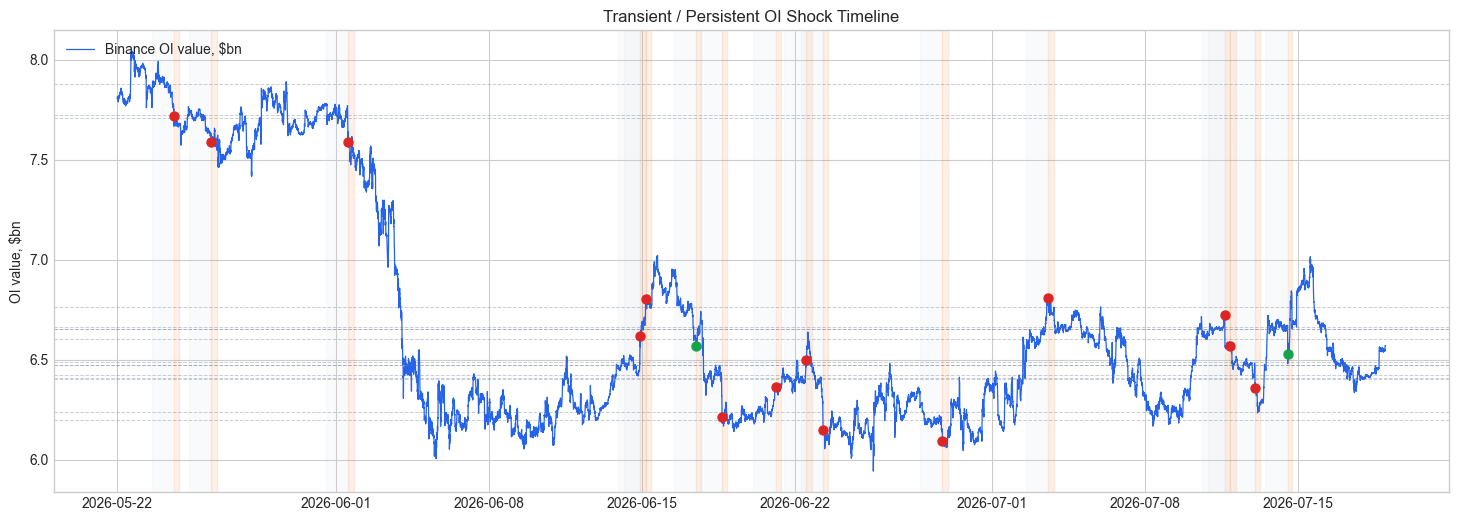

In [26]:
def plot_oi_shock_timeline(oi_frame: pd.DataFrame, shocks: pd.DataFrame, *, max_events: int = 12):
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(oi_frame['timestamp'], oi_frame['oi_value_usd'] / 1e9, color='#2563EB', linewidth=0.9, label='Binance OI value, $bn')

    if not shocks.empty:
        events = shocks.head(max_events)
        for row in events.itertuples(index=False):
            color = '#16A34A' if row.is_transient else '#DC2626'
            ax.axvspan(row.baseline_start, row.baseline_end, color='#CBD5E1', alpha=0.10)
            end_time = row.reversion_time if pd.notna(row.reversion_time) else row.event_time + pd.Timedelta(hours=6)
            ax.axvspan(row.event_time, end_time, color='#F97316', alpha=0.10)
            ax.axhline(row.baseline_median / 1e9, color='#64748B', linestyle='--', linewidth=0.7, alpha=0.35)
            ax.scatter(row.event_time, row.shock_value / 1e9, color=color, s=42, zorder=4)

    ax.set_title('Transient / Persistent OI Shock Timeline')
    ax.set_ylabel('OI value, $bn')
    ax.legend(loc='upper left')
    return fig, ax

fig, ax = plot_oi_shock_timeline(oi_df, oi_shocks, max_events=16)
plt.show()

이 그래프는 OI value 흐름 위에 shock 이벤트를 직접 표시한다. 회색 영역은 baseline window, 주황 영역은 shock 이후 reversion 확인 구간이며, 초록 점은 transient, 빨간 점은 persistent 이벤트다.

시각적으로는 OI가 평소 중심선에서 벗어난 뒤 다시 회귀하는지, 아니면 이탈 상태가 일정 시간 유지되는지를 확인할 수 있다.

## 9. Visualization: Reversion Fraction

`ReversionFraction`은 shock 이후 원래 baseline median으로 얼마나 돌아왔는지를 나타낸다.

- 낮을수록 원래 상태에 가깝게 복귀했다는 뜻이다.
- `max_reversion_fraction=0.35` 이하이면 transient로 본다.
- 0.35보다 크면 persistent로 본다.

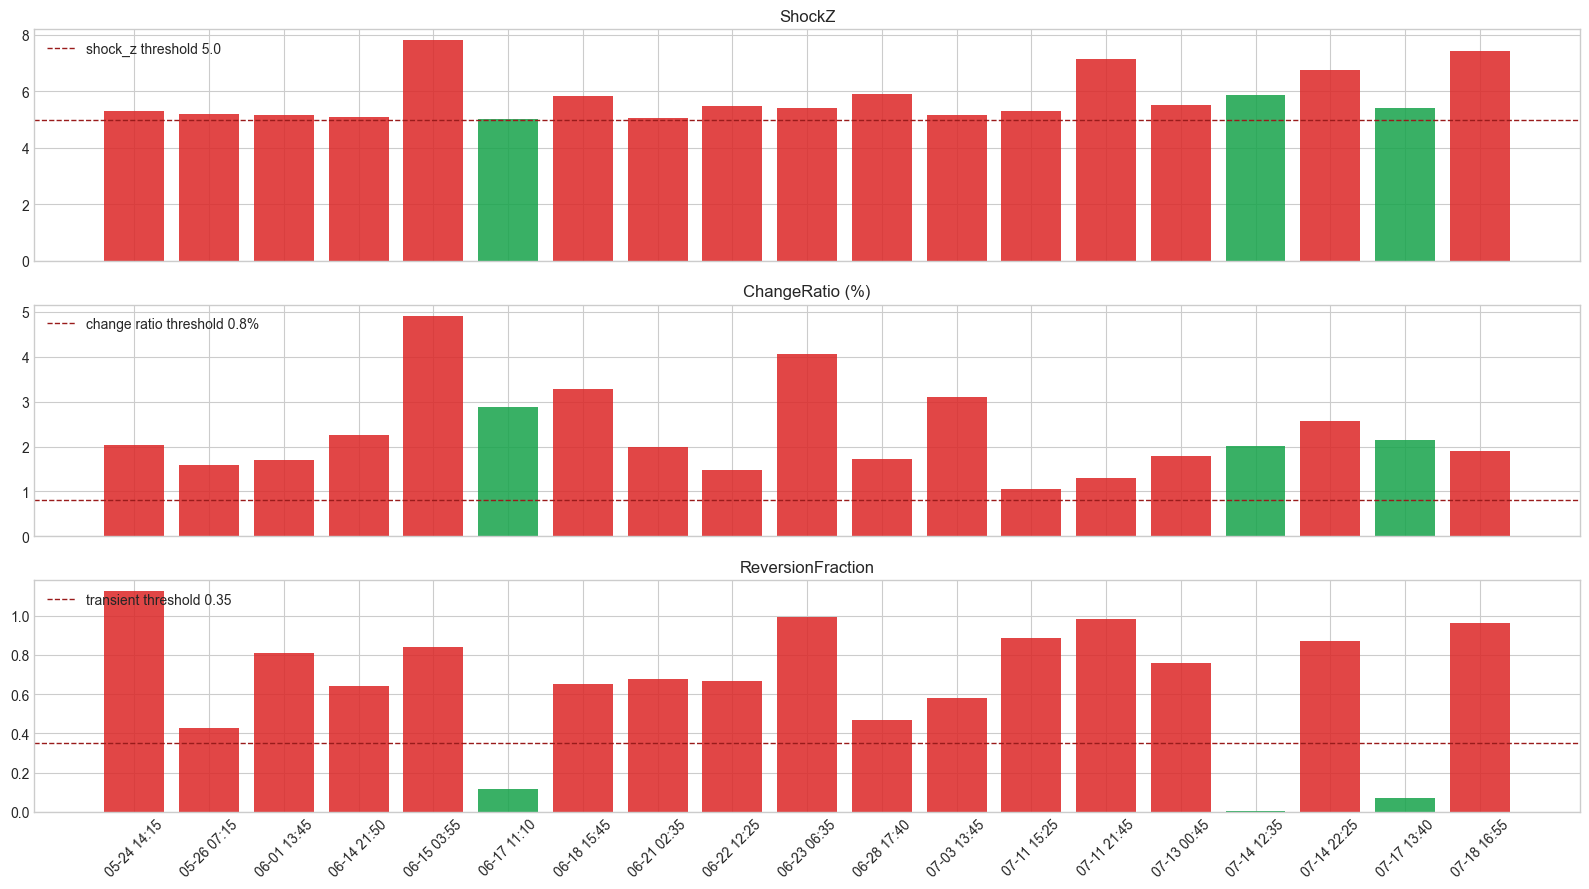

In [27]:
if oi_shocks.empty:
    print('No OI shocks detected.')
else:
    plot_df = oi_shocks.copy()
    plot_df['label'] = plot_df['event_time'].dt.strftime('%m-%d %H:%M')
    colors = np.where(plot_df['is_transient'], '#16A34A', '#DC2626')

    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
    axes[0].bar(plot_df['label'], plot_df['shock_z'], color=colors, alpha=0.85)
    axes[0].axhline(5.0, color='#991B1B', linestyle='--', linewidth=1, label='shock_z threshold 5.0')
    axes[0].set_title('ShockZ')
    axes[0].legend(loc='upper left')

    axes[1].bar(plot_df['label'], plot_df['change_ratio'] * 100, color=colors, alpha=0.85)
    axes[1].axhline(0.8, color='#991B1B', linestyle='--', linewidth=1, label='change ratio threshold 0.8%')
    axes[1].set_title('ChangeRatio (%)')
    axes[1].legend(loc='upper left')

    axes[2].bar(plot_df['label'], plot_df['reversion_fraction'], color=colors, alpha=0.85)
    axes[2].axhline(0.35, color='#991B1B', linestyle='--', linewidth=1, label='transient threshold 0.35')
    axes[2].set_title('ReversionFraction')
    axes[2].legend(loc='upper left')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

세 개의 막대 그래프는 각 shock 이벤트의 강도를 나누어 보여준다. 첫 번째는 `ShockZ`, 두 번째는 `ChangeRatio`, 세 번째는 `ReversionFraction`이다.

`ShockZ`와 `ChangeRatio`가 기준선을 넘으면 baseline 대비 충분히 큰 OI 충격으로 보고, `ReversionFraction`이 0.35 이하이면 transient로 분류한다. 현재 결과에서는 persistent 이벤트가 많기 때문에, 하단 그래프에서 0.35 위에 남는 이벤트가 상대적으로 많이 나타나는 구조다.


## 10. Price Context

Shock가 발생한 시점에 가격은 박스 안에 있었는지, 박스 돌파 근처였는지 함께 확인한다.

- 초록 세로선: Transient shock
- 빨간 세로선: Persistent shock
- 회색 음영: Price Box

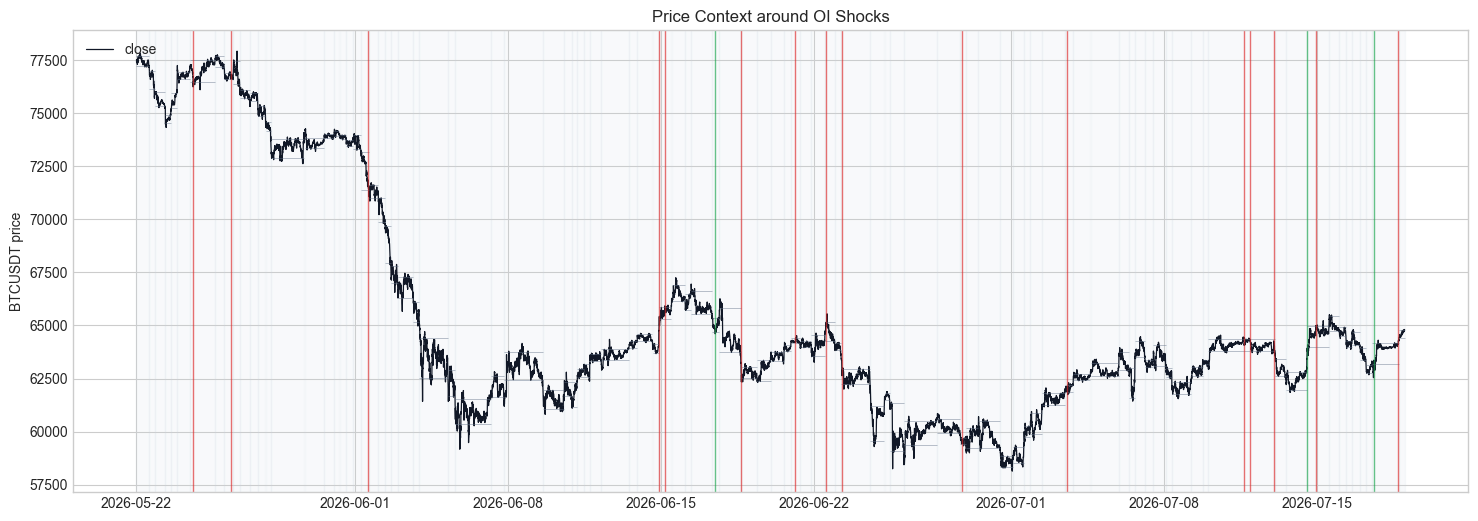

In [28]:
def plot_price_context_with_shocks(price_frame, price_boxes, shocks):
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(price_frame['timestamp'], price_frame['close'], color='#111827', linewidth=0.9, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.12)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.7, alpha=0.45)

    if not shocks.empty:
        for row in shocks.itertuples(index=False):
            color = '#16A34A' if row.is_transient else '#DC2626'
            ax.axvline(row.event_time, color=color, linewidth=1.0, alpha=0.65)

    ax.set_title('Price Context around OI Shocks')
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

fig, ax = plot_price_context_with_shocks(price_df, price_boxes, oi_shocks)
plt.show()

이 그래프는 가격 박스 위에 OI shock 시점을 겹쳐 보여준다. 회색 구간은 Price Box, 세로선은 OI shock 발생 시점이다.

핵심은 OI shock가 가격 박스 내부에서 발생했는지, 박스 이탈 근처에서 발생했는지를 확인하는 것이다. 만약 persistent shock가 가격 박스 돌파와 겹친다면 trend activation 후보가 될 수 있고, transient shock가 박스 내부에서 발생한다면 range 진입 회피용 risk-off 신호로 보는 편이 자연스럽다.


## 11. Backtest Design

Shock 신호를 전략에 넣는 방식을 비교한다.

### Scenario A: `without_oi_shock`

OI shock 정보를 사용하지 않는다.

### Scenario B: `transient_only_risk_off`

Transient shock만 사용한다. Transient 구간은 `risk_off=True`가 되어 range 진입을 막거나 기존 range 포지션을 정리한다.

### Scenario C: `full_transient_persistent`

Transient와 Persistent를 모두 사용한다.

- Transient: risk-off
- Persistent: `persistent_oi_direction`으로 표시되고, 가격이 박스를 돌파하면 trend-following 후보가 된다.

이 비교의 목적은 OI shock가 alpha signal인지, risk filter인지, 또는 trend activation signal인지 확인하는 것이다.

In [29]:
base_config = BoxStrategyConfig(
    entry_edge_ratio=0.08,
    bounce_confirm_bps=3.0,
    trailing_stop_bps=220.0,
    range_stop_buffer_bps=60.0,
    risk_per_trade=0.0015,
    max_leverage=0.70,
    max_holding_bars=288,
    require_oi_box_for_range=True,
    allow_short=True,
    fee_bps=4.0,
    slippage_bps=2.0,
    spread_bps=1.0,
)

candidate_configs = candidate_box_strategy_configs(
    base_config,
    entry_edge_ratios=(0.06, 0.08, 0.12, 0.18),
    bounce_confirm_bps_values=(0.0, 3.0, 8.0),
    trailing_stop_bps_values=(160.0, 220.0),
    range_stop_buffer_bps_values=(60.0, 110.0),
    risk_per_trade_values=(0.0015,),
)
print('candidate configs:', len(candidate_configs))

candidate configs: 48


후보 전략 파라미터는 총 **48개**다. `entry_edge_ratio`, `bounce_confirm_bps`, `trailing_stop_bps`, `range_stop_buffer_bps`를 바꿔가며 같은 shock filter가 여러 조건에서 어떻게 작동하는지 비교한다.

조합 수를 너무 크게 늘리지 않고 핵심 민감도만 확인하는 구조라, 포트폴리오에서는 과도한 최적화보다 ablation test에 가까운 검증으로 설명할 수 있다.


In [30]:
def shock_frame_for_scenario(scenario: str) -> pd.DataFrame:
    if oi_shocks.empty:
        return pd.DataFrame()
    if scenario == 'without_oi_shock':
        return pd.DataFrame()
    if scenario == 'transient_only_risk_off':
        return oi_shocks[oi_shocks['is_transient']].copy()
    if scenario == 'persistent_only_trend':
        return oi_shocks[oi_shocks['is_persistent']].copy()
    if scenario == 'full_transient_persistent':
        return oi_shocks.copy()
    raise ValueError(scenario)


def build_shock_strategy_frame(scenario: str, config: BoxStrategyConfig) -> pd.DataFrame:
    return build_box_strategy_frame(
        price_frame=price_df,
        oi_frame=oi_df,
        price_boxes=price_boxes,
        oi_boxes=oi_boxes,
        terminal_oi_volatility=pd.DataFrame(),
        transient_oi_shocks=shock_frame_for_scenario(scenario),
        deadcat_bounce_ranges=pd.DataFrame(),
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        oi_col='oi_value_usd',
        config=config,
    )


def run_shock_scenario(scenario: str):
    frame = build_shock_strategy_frame(scenario, base_config)
    result, report = optimize_box_strategy(
        frame,
        candidate_configs=candidate_configs,
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        min_win_rate=0.50,
        min_total_return=0.0,
        min_trades=5,
    )
    row = {
        'scenario': scenario,
        'passes_constraints': result.passes_constraints,
        'total_return_pct': result.metrics.get('total_return', np.nan) * 100,
        'win_rate_pct': result.metrics.get('win_rate', np.nan) * 100,
        'profit_factor': result.metrics.get('profit_factor', np.nan),
        'max_drawdown_pct': result.metrics.get('max_drawdown', np.nan) * 100,
        'total_trades': result.metrics.get('total_trades', np.nan),
    }
    return row, result, report

scenario_rows = []
scenario_results = {}
scenario_reports = {}

for scenario in [
    'without_oi_shock',
    'transient_only_risk_off',
    'persistent_only_trend',
    'full_transient_persistent',
]:
    row, result, report = run_shock_scenario(scenario)
    scenario_rows.append(row)
    scenario_results[scenario] = result
    scenario_reports[scenario] = report

result_summary = pd.DataFrame(scenario_rows)
result_summary

,scenario,passes_constraints,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades
0,without_oi_shock,True,14.564312,74.703557,2.623193,-0.751391,253.0
1,transient_only_risk_off,True,14.119219,75.000000,2.595115,-0.751391,248.0
2,persistent_only_trend,True,13.248370,70.722433,2.395038,-0.779030,263.0
3,full_transient_persistent,True,12.808389,70.930233,2.365988,-0.779030,258.0


네 가지 시나리오를 비교했다. 기준 전략인 `without_oi_shock`는 Total Return **14.56%**, Win Rate **74.70%**, Profit Factor **2.62**, MDD **-0.75%**다.

`transient_only_risk_off`는 Total Return이 **14.12%**로 소폭 낮지만 Win Rate는 **75.00%**로 약간 높고 거래 수는 248회로 줄었다. 반면 `persistent_only_trend`와 `full_transient_persistent`는 현재 조건에서는 수익률, 승률, PF가 기준 전략보다 낮다. 즉 persistent shock를 그대로 trend 신호로 쓰기에는 추가 확인이 필요하다.


## 11-1. Backtest Ablation Table

아래 셀은 OI shock 시나리오별 성과를 자동 문장으로 해석하지 않고, 기준 시나리오 대비 변화량을 `DataFrame`으로 정리한다.

비교 기준은 `without_oi_shock`이다.


In [31]:
def _scenario_row(summary: pd.DataFrame, scenario: str) -> pd.Series:
    rows = summary[summary['scenario'] == scenario]
    if rows.empty:
        raise ValueError(f'Missing scenario in result_summary: {scenario}')
    return rows.iloc[0]


def build_shock_backtest_ablation_table(summary: pd.DataFrame) -> pd.DataFrame:
    base = _scenario_row(summary, 'without_oi_shock')
    scenarios = [
        'transient_only_risk_off',
        'persistent_only_trend',
        'full_transient_persistent',
    ]

    rows = []
    for scenario in scenarios:
        row = _scenario_row(summary, scenario)
        rows.append({
            'scenario': scenario,
            'total_return_pct': round(float(row['total_return_pct']), 4),
            'delta_total_return_pct': round(float(row['total_return_pct'] - base['total_return_pct']), 4),
            'win_rate_pct': round(float(row['win_rate_pct']), 4),
            'delta_win_rate_pct': round(float(row['win_rate_pct'] - base['win_rate_pct']), 4),
            'profit_factor': round(float(row['profit_factor']), 4),
            'delta_profit_factor': round(float(row['profit_factor'] - base['profit_factor']), 4),
            'max_drawdown_pct': round(float(row['max_drawdown_pct']), 4),
            'delta_max_drawdown_pct': round(float(row['max_drawdown_pct'] - base['max_drawdown_pct']), 4),
            'total_trades': round(float(row['total_trades']), 4),
            'delta_trades': round(float(row['total_trades'] - base['total_trades']), 4),
        })

    return pd.DataFrame(rows)


shock_backtest_ablation_table = build_shock_backtest_ablation_table(result_summary)
shock_backtest_ablation_table

,scenario,total_return_pct,delta_total_return_pct,win_rate_pct,delta_win_rate_pct,profit_factor,delta_profit_factor,max_drawdown_pct,delta_max_drawdown_pct,total_trades,delta_trades
0,transient_only_risk_off,14.1192,-0.4451,75.0000,0.2964,2.5951,-0.0281,-0.7514,0.0000,248.0,-5.0
1,persistent_only_trend,13.2484,-1.3159,70.7224,-3.9811,2.3950,-0.2282,-0.7790,-0.0276,263.0,10.0
2,full_transient_persistent,12.8084,-1.7559,70.9302,-3.7733,2.3660,-0.2572,-0.7790,-0.0276,258.0,5.0


#### Backtest Ablation 해석

현재 실행 결과 기준 비교표는 다음과 같다.

| Scenario | Total Return | ΔTR | Win Rate | ΔWin | Profit Factor | ΔPF | MDD | ΔMDD | Trades | ΔTrades |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| without_oi_shock | 14.56% | 기준 | 74.70% | 기준 | 2.62 | 기준 | -0.75% | 기준 | 253 | 기준 |
| transient_only_risk_off | 14.12% | -0.45%p | 75.00% | +0.30%p | 2.60 | -0.03 | -0.75% | 0.00%p | 248 | -5 |
| persistent_only_trend | 13.25% | -1.32%p | 70.72% | -3.98%p | 2.40 | -0.23 | -0.78% | -0.03%p | 263 | +10 |
| full_transient_persistent | 12.81% | -1.76%p | 70.93% | -3.77%p | 2.37 | -0.26 | -0.78% | -0.03%p | 258 | +5 |

이 결과에서는 `transient_only_risk_off`가 총수익률은 소폭 낮아졌지만, 승률은 약간 개선되고 거래 수는 줄어든다. 즉 transient shock는 공격적인 진입 신호라기보다 일부 range 진입을 줄이는 보수적 risk-off 필터에 가깝다.

반대로 `persistent_only_trend`와 `full_transient_persistent`는 현재 조건에서는 기준 전략보다 Total Return, Win Rate, Profit Factor가 모두 낮다. 따라서 persistent shock를 바로 trend-following 진입 신호로 쓰기에는 아직 부족하고, 가격 박스 돌파 강도, 거래량, 체결 흐름 같은 추가 confirmation이 필요하다.


## 12. Backtest Result Visualization

주요 성과 지표를 시나리오별로 비교한다.

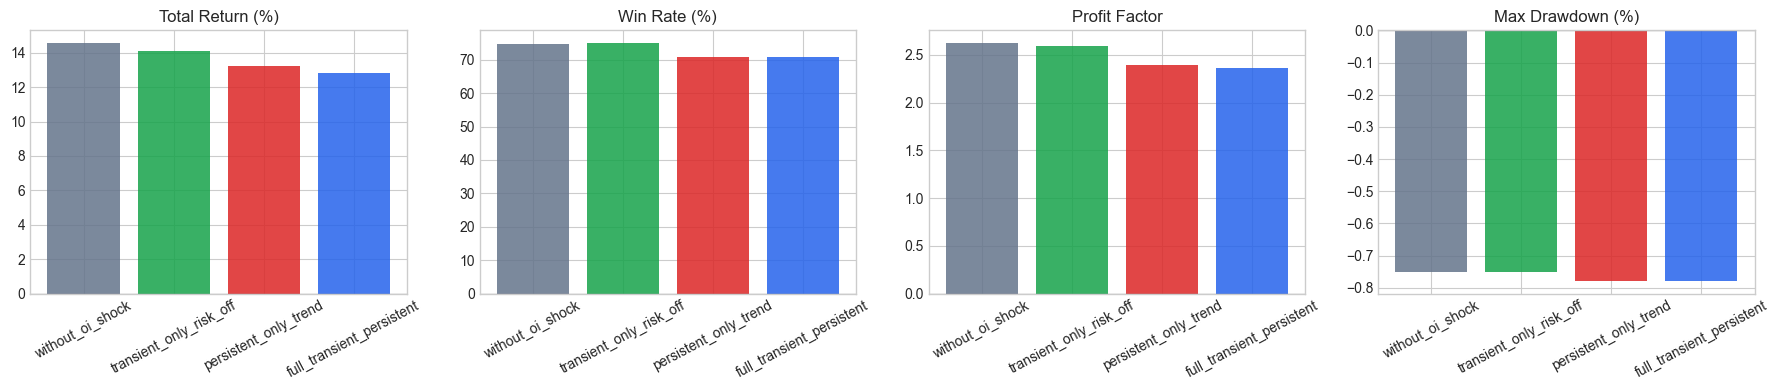

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics_to_plot = [
    ('total_return_pct', 'Total Return (%)'),
    ('win_rate_pct', 'Win Rate (%)'),
    ('profit_factor', 'Profit Factor'),
    ('max_drawdown_pct', 'Max Drawdown (%)'),
]
color_map = {
    'without_oi_shock': '#64748B',
    'transient_only_risk_off': '#16A34A',
    'persistent_only_trend': '#DC2626',
    'full_transient_persistent': '#2563EB',
}
colors = [color_map.get(s, '#94A3B8') for s in result_summary['scenario']]

for ax, (col, title) in zip(axes, metrics_to_plot):
    ax.bar(result_summary['scenario'], result_summary[col], color=colors, alpha=0.85)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=28)
    ax.axhline(0, color='#111827', linewidth=0.8)

plt.tight_layout()
plt.show()

막대 그래프는 시나리오별 Total Return, Win Rate, Profit Factor, Max Drawdown을 한 화면에서 비교한다. 기준 전략 대비 `transient_only_risk_off`는 방어적 변화가 작게 나타나지만, persistent를 trend로 사용하는 시나리오는 성과 지표가 약해진다.

이 결과는 OI shock를 무조건 진입 신호로 쓰기보다, transient/persistent의 역할을 분리해 검증해야 한다는 점을 보여준다.


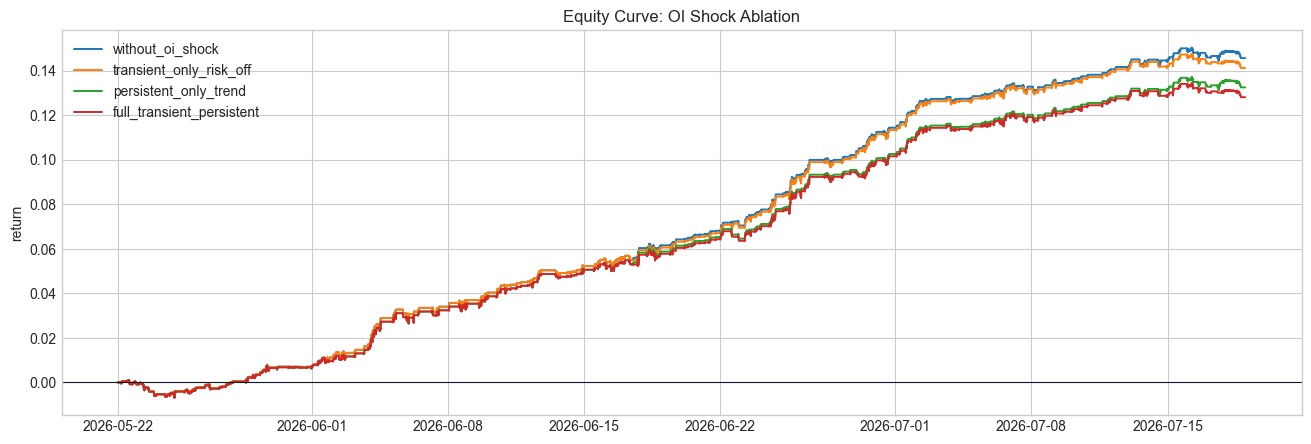

In [33]:
fig, ax = plt.subplots(figsize=(16, 5))
for name, result in scenario_results.items():
    curve = result.equity_curve.copy()
    if curve.empty:
        continue
    initial = curve['equity'].iloc[0]
    ax.plot(curve['timestamp'], curve['equity'] / initial - 1.0, label=name, linewidth=1.4)
ax.axhline(0, color='#111827', linewidth=0.8)
ax.set_title('Equity Curve: OI Shock Ablation')
ax.set_ylabel('return')
ax.legend()
plt.show()

Equity Curve는 각 시나리오의 누적 성과 흐름을 비교한다. 최종 수익률뿐 아니라 중간 경로의 흔들림과 회복 속도를 함께 볼 수 있다.

현재 결과에서는 기준 전략이 가장 높은 누적 수익률을 보이며, shock filter 시나리오는 일부 구간에서 거래를 줄이거나 방향 조건을 바꾸면서 최종 곡선이 낮아진다. 


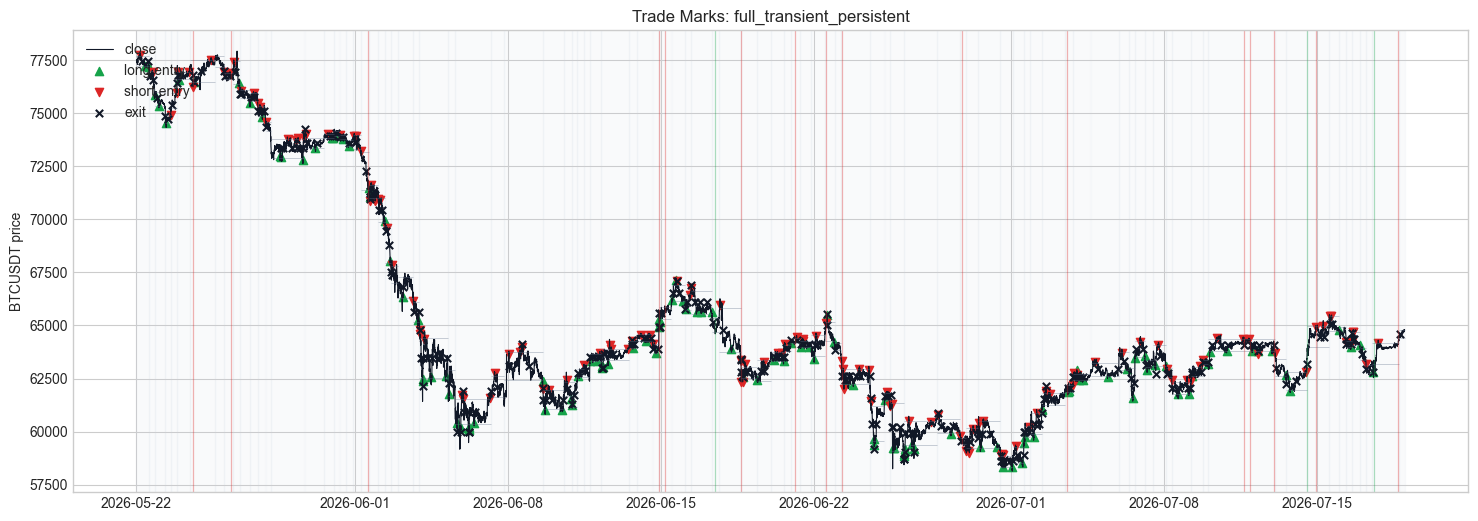

In [34]:
def plot_trade_marks_with_shocks(result, title: str):
    trades = result.trades.copy()
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(price_df['timestamp'], price_df['close'], color='#111827', linewidth=0.8, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.10)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.6, alpha=0.40)

    if not oi_shocks.empty:
        for row in oi_shocks.itertuples(index=False):
            color = '#16A34A' if row.is_transient else '#DC2626'
            ax.axvline(row.event_time, color=color, linewidth=0.9, alpha=0.35)

    if not trades.empty:
        long_entries = trades[trades['direction'] > 0]
        short_entries = trades[trades['direction'] < 0]
        ax.scatter(long_entries['entry_time'], long_entries['entry_price'], marker='^', s=35, color='#16A34A', label='long entry')
        ax.scatter(short_entries['entry_time'], short_entries['entry_price'], marker='v', s=35, color='#DC2626', label='short entry')
        ax.scatter(trades['exit_time'], trades['exit_price'], marker='x', s=28, color='#111827', label='exit')

    ax.set_title(title)
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

selected_name = 'full_transient_persistent' if 'full_transient_persistent' in scenario_results else next(iter(scenario_results))
fig, ax = plot_trade_marks_with_shocks(scenario_results[selected_name], f'Trade Marks: {selected_name}')
plt.show()

이 차트는 가격, Price Box, OI shock, 실제 진입/청산 지점을 한 번에 겹쳐 보여준다. 진입 마커가 shock 세로선과 겹치는지, shock 이후 거래 방향이 어떻게 바뀌는지를 확인할 수 있다.

특히 `full_transient_persistent` 시나리오에서 persistent shock 이후 trend 진입이 실제로 좋은 위치에서 발생했는지 확인하는 용도다. 성과표만으로는 어떤 거래가 필터링되었는지 알기 어렵기 때문에, 이 그래프는 전략 행동을 검증하는 역할을 한다.


## 13. Top Configs

각 시나리오에서 optimizer가 선택한 상위 후보를 확인한다.

In [35]:
for name, report in scenario_reports.items():
    print('\n===', name, 'top configs ===')
    display_cols = [
        'passes_constraints', 'entry_edge_ratio', 'bounce_confirm_bps', 'trailing_stop_bps',
        'range_stop_buffer_bps', 'risk_per_trade', 'total_return', 'win_rate',
        'profit_factor', 'max_drawdown', 'total_trades',
    ]
    available = [col for col in display_cols if col in report.columns]
    display(report[available].head(10))


=== without_oi_shock top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,160.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
1,True,0.08,3.0,220.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
2,True,0.08,8.0,160.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
3,True,0.08,8.0,220.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
4,True,0.08,0.0,160.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
5,True,0.08,0.0,220.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
6,True,0.12,8.0,160.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
7,True,0.12,8.0,220.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
8,True,0.12,3.0,160.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0
9,True,0.12,3.0,220.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0



=== transient_only_risk_off top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,160.0,60.0,0.0015,0.141192,0.750000,2.595115,-0.007514,248.0
1,True,0.08,3.0,220.0,60.0,0.0015,0.141192,0.750000,2.595115,-0.007514,248.0
2,True,0.08,8.0,160.0,60.0,0.0015,0.135992,0.757426,2.921893,-0.004545,202.0
3,True,0.08,8.0,220.0,60.0,0.0015,0.135992,0.757426,2.921893,-0.004545,202.0
4,True,0.08,0.0,160.0,60.0,0.0015,0.135870,0.742049,2.282775,-0.007427,283.0
5,True,0.08,0.0,220.0,60.0,0.0015,0.135870,0.742049,2.282775,-0.007427,283.0
6,True,0.12,8.0,160.0,60.0,0.0015,0.130988,0.759494,2.573969,-0.006948,237.0
7,True,0.12,8.0,220.0,60.0,0.0015,0.130988,0.759494,2.573969,-0.006948,237.0
8,True,0.12,3.0,160.0,60.0,0.0015,0.129453,0.749153,2.239864,-0.007568,295.0
9,True,0.12,3.0,220.0,60.0,0.0015,0.129453,0.749153,2.239864,-0.007568,295.0



=== persistent_only_trend top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,220.0,60.0,0.0015,0.132484,0.707224,2.395038,-0.007790,263.0
1,True,0.08,8.0,220.0,60.0,0.0015,0.130568,0.712963,2.734532,-0.004545,216.0
2,True,0.08,3.0,160.0,60.0,0.0015,0.130206,0.707224,2.341933,-0.007902,263.0
3,True,0.08,8.0,160.0,60.0,0.0015,0.128484,0.712963,2.663903,-0.004545,216.0
4,True,0.08,0.0,220.0,60.0,0.0015,0.127606,0.707071,2.139793,-0.007686,297.0
5,True,0.08,0.0,160.0,60.0,0.0015,0.125489,0.707071,2.101985,-0.007798,297.0
6,True,0.12,8.0,220.0,60.0,0.0015,0.125206,0.717131,2.426988,-0.007271,251.0
7,True,0.12,3.0,220.0,60.0,0.0015,0.123062,0.717532,2.133235,-0.007844,308.0
8,True,0.12,8.0,160.0,60.0,0.0015,0.122985,0.717131,2.370105,-0.007383,251.0
9,True,0.12,3.0,160.0,60.0,0.0015,0.120938,0.717532,2.094364,-0.007956,308.0



=== full_transient_persistent top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,220.0,60.0,0.0015,0.128084,0.709302,2.365988,-0.007790,258.0
1,True,0.08,8.0,220.0,60.0,0.0015,0.126040,0.715640,2.701214,-0.004545,211.0
2,True,0.08,3.0,160.0,60.0,0.0015,0.125815,0.709302,2.312923,-0.007902,258.0
3,True,0.08,8.0,160.0,60.0,0.0015,0.123964,0.715640,2.630430,-0.004545,211.0
4,True,0.08,0.0,220.0,60.0,0.0015,0.123225,0.708904,2.112684,-0.007686,292.0
5,True,0.08,0.0,160.0,60.0,0.0015,0.121116,0.708904,2.074999,-0.007798,292.0
6,True,0.12,8.0,220.0,60.0,0.0015,0.120700,0.719512,2.394527,-0.007271,246.0
7,True,0.12,3.0,220.0,60.0,0.0015,0.118699,0.719472,2.105221,-0.007844,303.0
8,True,0.12,8.0,160.0,60.0,0.0015,0.118487,0.719512,2.337709,-0.007383,246.0
9,True,0.12,3.0,160.0,60.0,0.0015,0.116583,0.719472,2.066484,-0.007956,303.0


각 시나리오별 optimizer 상위 조합을 출력한다. 같은 shock 신호라도 `entry_edge_ratio`, `bounce_confirm_bps`, `trailing_stop_bps`, `range_stop_buffer_bps` 조합에 따라 성과가 달라지는지 확인할 수 있다.

상위 조합에서 반복적으로 선택되는 파라미터가 있다면 전략 구조가 비교적 안정적이라는 근거가 되고, 특정 조합 하나에만 성과가 몰리면 과최적화 가능성을 의심해야 한다.


## 15. Interpretation

Transient / Persistent OI Shock는 다음처럼 정리할 수 있다.

1. OI shock는 평소 OI 중심에서 크게 벗어난 이벤트다.
2. Shock 이후 baseline median 근처로 돌아오면 transient다.
3. Shock 이후 높은/낮은 상태가 유지되면 persistent다.
4. Transient는 단독 진입 신호보다 risk-off 필터에 가깝다.
5. Persistent는 가격 박스 돌파와 결합될 때 trend-following 후보가 된다.

따라서 이 신호는 “OI가 튀었으니 바로 매수/매도”가 아니라, **충격 이후 시장 상태가 되돌아왔는지 유지되는지 구분하는 regime signal**로 보는 것이 적합하다.

## 16. Limitations & Next Steps

한계:

- Binance 단일 거래소 OI 중심 실험이다.
- 분석 구간이 제한적이므로 더 긴 과거 데이터에서 재검증해야 한다.
- OI shock 방향만으로 가격 방향을 단정할 수 없다.
- Persistent shock는 가격 box breakout, 체결강도, orderbook update intensity와 결합해 해석해야 한다.

다음 단계:

- Binance 외 Bybit/Bitget/OKX OI를 합산한 cross-exchange shock 비교
- Persistent shock 이후 breakout 성공률 측정
- Transient shock 이후 range mean-reversion 회복 여부 측정
- shock threshold와 reversion window에 대한 민감도 분석
- shock 이후 포지션 축소, 진입 금지, trend activation을 각각 분리한 risk action 비교